# Claims / payment-integrity ML with noisy reviewer labels — walkthrough, part 1

**Project role.** A portfolio starting point for ML roles in health-plan claims / payment integrity.
Synthetic claims only, no PHI, CPU-only, deterministic. This notebook is not production evidence, and every
claim below carries an explicit label.

**What this notebook does (five stages).** (1) understand the synthetic claim stream and its known latent
truth; (2) build as-of (no-peeking) features, splits, label aggregation and the run ledger; (3) fit a naive
single-verdict scorer and a noise-aware CCEM scorer, then stress CCEM identifiability; (4) show the real
4-seed exec figure and the live 2-seed paired stress; (5) report monitor operating characteristics honestly.

**Claim labels used in every section** (definitions from `research/notebook-research-context.md`):

| label | meaning |
| --- | --- |
| source-backed | directly tied to an equation, theorem or assumption in one of the three papers and traceable to a raw NotebookLM answer slug |
| derived here | synthetic generator, feature, metric, stress arm, monitor or visualization chosen by this project |
| out of scope | real PHI, production performance, or top-K / population guarantees not measured here |

**Palette (Okabe–Ito) used across the notebook.**

| role | hex |
| --- | --- |
| primary / control | #0072B2 |
| stress / secondary | #D55E00 |
| third series | #009E73 |
| fourth series | #E69F00 |
| fifth series | #CC79A7 |

**Raw-query locators** used in this notebook: `q2` (CCEM Eq. (1)–(3), Eq. (6a)-(6b), Theorem 1) and `q9`
(SCoRC Assumption 6, three-split protocol). Local traces: `nlm/responses/t3-papers-q2.json`,
`nlm/responses/t3-papers-q9.json`. Reference figure sidecar: `exec/figures/01_identifiability.csv`
(produced by `exec/make_figures.py`); `viz/mock` is never used.

In [1]:
from pathlib import Path
import csv
import sys
import time
import warnings

import numpy as np

def find_project_root(start: Path) -> Path:
    # Walk up from the working directory until exec/claims_integrity is found.
    for candidate in [start, *start.parents]:
        if (candidate / "exec" / "claims_integrity").is_dir():
            return candidate
    raise RuntimeError(f"exec/claims_integrity not found above {start}")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import exec.claims_integrity as ci

%matplotlib inline

PALETTE = {
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "yellow": "#E69F00",
    "pink": "#CC79A7",
}
print(f"check 1: cwd={Path.cwd()} | project root={PROJECT_ROOT}")
print(f"check 1: package version={ci.PACKAGE_VERSION} | config scenario={ci.CONFIG['scenario']} | "
      f"numpy={np.__version__} | matplotlib backend={plt.get_backend()}")

check 1: cwd=/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-3/leakage-proof-timeseries/claims-payment-integrity-labels/notebooks | project root=/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-3/leakage-proof-timeseries/claims-payment-integrity-labels
check 1: package version=1.0.0 | config scenario=synthetic-claims-v1 | numpy=2.5.3 | matplotlib backend=inline


## Stage 1 - Data understanding

The stream is this project's synthetic claim stream with **known latent truth**. Its reviewer model follows
the CCEM observed-response equations (LaTeX stripped for readability):

> "`p_n^{(m)} = A_m f(x_n)`, for all `m in [M], n in [N]` — Eq. (2)"
> "`y_hat_n^{(m)} ~ Cart(p_n^{(m)})` — Eq. (3)"
> — q2: CCEM Eq. (1)-(3), `nlm/responses/t3-papers-q2.json`

**source-backed**: the reviewer-noise response equations (CCEM Eq. (1)–(3)).
**derived here**: everything else in this stage — the generator, class priors, billed/recoverable dollar
proxies, the ambiguity rule, the reviewer mix and the control/stress regimes. Rows below are measured on the
canonical stream `seed=11`, `n=int(ci.CONFIG["n_claims"])`, `regime="anchored"`.

**Two regimes, one budget (control vs stress).**

| regime | reviewer assignment | what it tests |
| --- | --- | --- |
| `anchored` | each claim goes to 3 uniformly random reviewers, so every reviewer sees every latent class | the CCEM control: the reviewer x class coverage graph is roughly connected (NCSA/NAPA-flavoured anchors exist) |
| `specialist_weak_anchor` | specialty queues built from the model-implied class score; each specialist's two non-specialty response columns are merged | the stress arm: a reviewer x class coverage break where the merged response cannot be cross-checked by another reviewer group, so identifiability degrades |

Both regimes are **derived here** stress constructions (the specialist / weak-anchor adaptation is
documented against `q4`); Stage 3 and Stage 4 *measure* the consequence rather than asserting a theorem.

In [2]:
N = int(ci.CONFIG["n_claims"])
SEED = int(ci.CONFIG["seeds"][0])

t0 = time.perf_counter()
stream = ci.make_claim_stream(seed=SEED, n=N, regime="anchored")
generate_seconds = time.perf_counter() - t0
digest = ci.stream_digest(stream)

y_latent = stream["latent_overpayment"]
positive_dollars = stream["recoverable_dollars"][y_latent]
prevalence = float(y_latent.mean())
ambiguous_share = float(stream["ambiguous"].mean())
median_dollars = float(np.median(positive_dollars))
q99_dollars = float(np.quantile(positive_dollars, 0.99))
typology_counts = {
    name: int((stream["typology"] == name).sum())
    for name in ("compliant", "billing_error", "medically_unnecessary")
}
typology_shares = {name: round(count / N, 4) for name, count in typology_counts.items()}
reviewed = stream["reviewer_id"] >= 0
labels_per_item = (stream["reviewer_label_matrix"] >= 0).sum(axis=1)
pair_agreement = ci.pairwise_agreement(stream["reviewer_label_matrix"])

print(f"check 2: canonical stream seed={SEED} n={N} regime={stream['regime']} "
      f"features={stream['features'].shape} reviewers={ci.CONFIG['n_reviewers']} generated in {generate_seconds:.2f}s")
print(f"check 2: stream digest = {digest}")
print(f"check 3: overpayment prevalence = {prevalence:.4f} (expected inside (0.005, 0.20))")
assert 0.005 < prevalence < 0.20, "overpayment prevalence left the expected rare-event band"
print(f"check 4: ambiguous share = {ambiguous_share:.4f} (expected > 0.02)")
assert ambiguous_share > 0.02, "ambiguous mass disappeared from the stream"
print(f"check 5: positive recoverable dollars mean={positive_dollars.mean():,.0f} "
      f"median={median_dollars:,.0f} q99={q99_dollars:,.0f}; q99 / (3 x median) = "
      f"{q99_dollars / (3.0 * median_dollars):.2f}x")
assert q99_dollars > 3.0 * median_dollars, "heavy-tail check failed: q99 is not above 3x the median"
print(f"check 6: typology counts {typology_counts}; shares {typology_shares}")
assert typology_counts["billing_error"] > 0 and typology_counts["medically_unnecessary"] > 0, "a typology is empty"
print(f"check 7: reviewer exposure: share of claims reviewed = {reviewed.mean():.3f}; "
      f"labels per item mean={labels_per_item.mean():.2f}; positive reviewer votes per reviewed claim mean="
      f"{(stream['reviewer_label_matrix'] > 0).sum(axis=1)[reviewed].mean():.2f}")
print(f"check 8: global pairwise reviewer agreement = {pair_agreement:.4f}")
assert 0.0 <= pair_agreement <= 1.0

check 2: canonical stream seed=11 n=1500 regime=anchored features=(1500, 10) reviewers=6 generated in 0.01s
check 2: stream digest = 7b5d42b039401c3d29c06fe605427719b563171a1efb995a33ea38601ef65e2c
check 3: overpayment prevalence = 0.0507 (expected inside (0.005, 0.20))
check 4: ambiguous share = 0.0780 (expected > 0.02)
check 5: positive recoverable dollars mean=993 median=265 q99=15,435; q99 / (3 x median) = 19.41x
check 6: typology counts {'compliant': 1424, 'billing_error': 54, 'medically_unnecessary': 22}; shares {'compliant': 0.9493, 'billing_error': 0.036, 'medically_unnecessary': 0.0147}
check 7: reviewer exposure: share of claims reviewed = 1.000; labels per item mean=3.00; positive reviewer votes per reviewed claim mean=0.85
check 8: global pairwise reviewer agreement = 0.6024


How to read this chart. Two bars per claim typology. Blue is the typology's share of the stream under the
**known latent truth**; orange is the share of the reviewer **single-verdict overpayment flags** that carry
that typology. Orange mass on `compliant` is reviewer false-positive noise; orange falling below the blue bar
for `billing_error` / `medically_unnecessary` is overpayment the reviewers missed. These are derived-here
measurements on the canonical stream, not a property of real review teams.

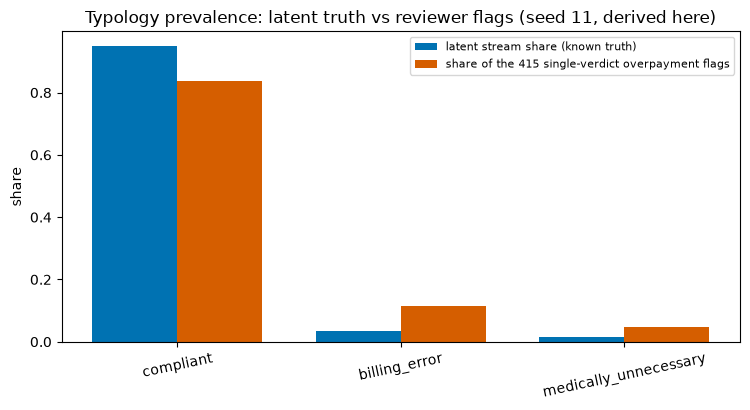

In [3]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
typology_names = ["compliant", "billing_error", "medically_unnecessary"]
latent_share = np.array([(stream["typology"] == name).mean() for name in typology_names])
flagged = stream["reviewer_labels"] > 0
flagged_share = np.array([
    ((stream["typology"] == name) & flagged).sum() / max(int(flagged.sum()), 1) for name in typology_names
])
positions = np.arange(len(typology_names))
width = 0.38
ax.bar(positions - width / 2, latent_share, width=width, color=PALETTE["blue"],
       label="latent stream share (known truth)")
ax.bar(positions + width / 2, flagged_share, width=width, color=PALETTE["orange"],
       label=f"share of the {int(flagged.sum())} single-verdict overpayment flags")
ax.set_xticks(positions, typology_names, rotation=12)
ax.set_ylabel("share")
ax.set_title("Typology prevalence: latent truth vs reviewer flags (seed 11, derived here)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

How to read this chart. Distribution of `recoverable_dollars` over the claims the latent truth marks as
overpaid; the x-axis is log-scaled because the tail spans orders of magnitude. The dashed line is the median
and the dotted line the 99th percentile — the gap between them is the heavy tail. Population dollar sums are
dominated by a handful of claims, which is why the pipeline carries a dollar-weighting step and why Stage 3
ranks with precision@K rather than averaging. Derived here.

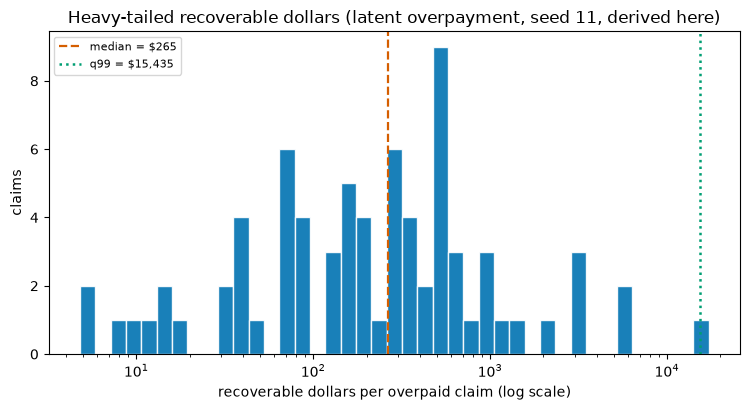

In [4]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
bins = np.logspace(np.log10(max(positive_dollars.min(), 1.0)), np.log10(positive_dollars.max()), 42)
ax.hist(positive_dollars, bins=bins, color=PALETTE["blue"], edgecolor="white", alpha=0.9)
ax.set_xscale("log")
ax.axvline(median_dollars, color=PALETTE["orange"], linestyle="--", linewidth=1.6,
           label=f"median = ${median_dollars:,.0f}")
ax.axvline(q99_dollars, color=PALETTE["green"], linestyle=":", linewidth=1.8,
           label=f"q99 = ${q99_dollars:,.0f}")
ax.set_xlabel("recoverable dollars per overpaid claim (log scale)")
ax.set_ylabel("claims")
ax.set_title("Heavy-tailed recoverable dollars (latent overpayment, seed 11, derived here)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Stage 2 - Pre-processing

Pre-processing is where the no-peeking guarantee is created: provider-level aggregates enter a claim only if
they come from **strictly earlier** claims of the same provider (as-of adjudication day). The three-way split
follows the source's disjoint-split protocol:

> "The dataset is partitioned into disjoint i.i.d. splits `D_tr ⊔ D_tune ⊔ D_cert ~ P_XY`."
> — q9: SCoRC Assumption 6 (three-split protocol), `nlm/responses/t3-papers-q9.json`

**source-backed**: the disjoint train/tune/certification protocol.
**derived here**: the as-of provider aggregates, the mutation leakage probe, multi-reviewer label
aggregation, dollar weighting and the run ledger. The certification split is not used for any guarantee
here — it is held back for NB3.

Ledger fields written by `ci.record_run`:

| field | meaning |
| --- | --- |
| seed | stream / scorer seed |
| config_hash | canonical SHA-256 of the frozen `ci.CONFIG` (schema `claims-integrity-config-v1`) |
| capacity | reviewer capacity in claims that the row is quoted at |
| runtime_seconds | measured wall-clock for the corresponding stage |

In [5]:
t0 = time.perf_counter()
X, feature_names = ci.build_features(stream)
probe = ci.no_leakage_probe(stream)

print(f"check 9: feature matrix shape = {X.shape}; {len(feature_names)} feature names")
print(f"check 9: feature names = {feature_names}")
assert X.shape == (N, len(feature_names)) and np.isfinite(X).all(), "feature matrix shape/finiteness broke"
print(f"check 10: ci.no_leakage_probe -> ok={probe['ok']} checked={probe['checked']} "
      f"probes_with_future={probe['probes_with_future']}")
assert probe["ok"] is True and probe["checked"] > 0 and probe["probes_with_future"] > 0

# Independent mutation demonstration: the probe must not be vacuous.
rng = np.random.default_rng(7)
probe_idx, future_mask = None, None
for candidate in rng.choice(N, size=400, replace=False):
    future = (stream["adjudication_day"] > stream["adjudication_day"][candidate]) & (
        stream["provider_id"] == stream["provider_id"][candidate]
    )
    if future.sum() >= 2:
        probe_idx, future_mask = int(candidate), future
        break
assert probe_idx is not None, "no probe claim with two or more later same-provider claims"
mutated = dict(stream)
mutated["billed"] = stream["billed"].copy()
mutated["observed_overpayment"] = stream["observed_overpayment"].copy()
mutated["billed"][future_mask] = stream["billed"][future_mask] * 3.0 + 1000.0
mutated["observed_overpayment"][future_mask] = 1 - np.clip(stream["observed_overpayment"][future_mask], 0, 1)
X_mutated, _ = ci.build_features(mutated)
probe_row_identical = bool(np.array_equal(X[probe_idx], X_mutated[probe_idx]))
future_rows_changed = bool(not np.array_equal(X[future_mask], X_mutated[future_mask]))
print(f"check 11: mutation probe on claim {probe_idx} ({int(future_mask.sum())} later same-provider claims mutated): "
      f"probe row bit-identical = {probe_row_identical}; mutated future rows changed = {future_rows_changed}")
assert probe_row_identical and future_rows_changed, "the leakage probe is vacuous or the row changed"

check 9: feature matrix shape = (1500, 14); 14 feature names
check 9: feature names = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'log_billed', 'provider_past_claims', 'provider_past_billed_mean', 'provider_past_overpay_rate']
check 10: ci.no_leakage_probe -> ok=True checked=25 probes_with_future=25
check 11: mutation probe on claim 1058 (17 later same-provider claims mutated): probe row bit-identical = True; mutated future rows changed = True


In [6]:
splits = ci.three_way_split(N, SEED)
train_idx, tune_idx, cert_idx = splits["train"], splits["tune"], splits["cert"]
sizes = {name: int(len(idx)) for name, idx in splits.items()}
disjoint = (
    len(set(train_idx) & set(tune_idx)) == 0
    and len(set(train_idx) & set(cert_idx)) == 0
    and len(set(tune_idx) & set(cert_idx)) == 0
)
covered = len(set(train_idx) | set(tune_idx) | set(cert_idx)) == N
print(f"check 12: split sizes train/tune/cert = {sizes['train']}/{sizes['tune']}/{sizes['cert']}; "
      f"disjoint={disjoint}; union covers all {N} claims={covered}")
assert disjoint and covered and sum(sizes.values()) == N

label_counts = (stream["reviewer_label_matrix"] >= 0).sum(axis=1)
positive_votes = (stream["reviewer_label_matrix"] > 0).sum(axis=1)
label_hist = {int(k): int((label_counts == k).sum()) for k in range(0, ci.CONFIG["n_reviewers"] + 1)}
vote_hist = {int(k): int((positive_votes == k).sum()) for k in range(0, ci.CONFIG["n_reviewers"] + 1)}
print(f"check 13: aggregated labels per item histogram (0..6 reviewers) = {label_hist}")
print(f"check 13: positive reviewer votes per item histogram = {vote_hist}")

all_dollars = float(stream["recoverable_dollars"].sum())
reviewed_dollars = float(stream["recoverable_dollars"][reviewed].sum())
print(f"check 14: dollar weighting: latent recoverable dollars = ${all_dollars:,.0f}; carried by reviewed "
      f"claims = ${reviewed_dollars:,.0f} ({reviewed_dollars / all_dollars:.3f} of the total; the anchored "
      f"control reviews every claim, so this is the whole pool); declared cost per review = "
      f"${ci.CONFIG['cost_per_review']:,.2f} (minutes_per_review={ci.CONFIG['minutes_per_review']}, "
      f"cost_per_minute={ci.CONFIG['cost_per_minute']})")

preprocess_seconds = time.perf_counter() - t0
ledger_row = ci.record_run(seed=SEED, config=ci.CONFIG, capacity=100, runtime_seconds=preprocess_seconds)
print(f"check 15: pre-processing runtime = {preprocess_seconds:.2f}s")
print(f"check 15: ledger seed={ledger_row['seed']} config_hash={ledger_row['config_hash']} "
      f"capacity={ledger_row['capacity']} runtime_seconds={ledger_row['runtime_seconds']:.2f}")
assert ledger_row["config_hash"] == ci.config_hash(ci.CONFIG)
assert len(ledger_row["config_hash"]) == 64 and all(c in "0123456789abcdef" for c in ledger_row["config_hash"])
RUNTIMES = {"preprocess": preprocess_seconds, "generate": generate_seconds}

check 12: split sizes train/tune/cert = 600/300/600; disjoint=True; union covers all 1500 claims=True
check 13: aggregated labels per item histogram (0..6 reviewers) = {0: 0, 1: 0, 2: 0, 3: 1500, 4: 0, 5: 0, 6: 0}
check 13: positive reviewer votes per item histogram = {0: 614, 1: 585, 2: 213, 3: 88, 4: 0, 5: 0, 6: 0}
check 14: dollar weighting: latent recoverable dollars = $75,478; carried by reviewed claims = $75,478 (1.000 of the total; the anchored control reviews every claim, so this is the whole pool); declared cost per review = $12.00 (minutes_per_review=3.0, cost_per_minute=1.5)
check 15: pre-processing runtime = 0.14s
check 15: ledger seed=11 config_hash=0066ca74e7e7418595d2a36e38d6004df7946fabb10c2e01ec79594132b9dbd2 capacity=100 runtime_seconds=0.14


How to read this chart. Left panel: how many reviewer labels each claim carries. In the `anchored`
control every claim is routed to exactly 3 of the 6 reviewers, so the support sits on a single bar — this is
a design fact of the derived generator, and it is what makes the multi-reviewer aggregation possible.
Right panel: how many of those 3 verdicts flag overpayment (0 to 3). The mass at 0 and 3 is reviewer
disagreement made visible; the middle bars are the genuinely contested claims that a naive single-verdict
training set collapses into one label. Derived here.

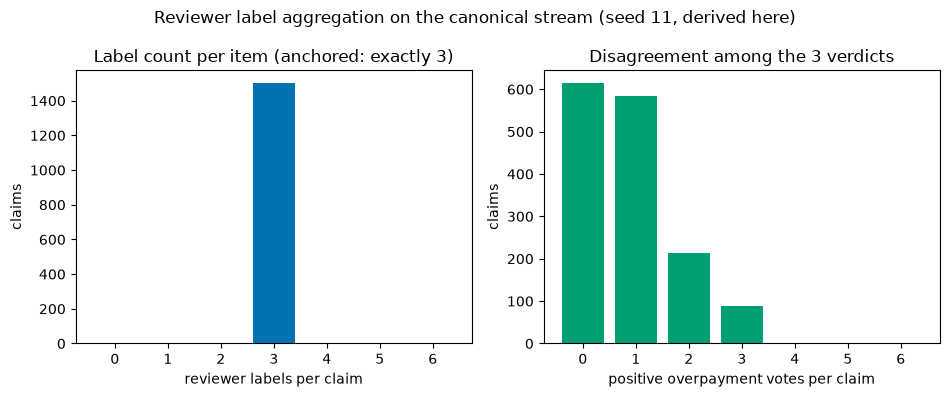

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0))
support = np.arange(0, ci.CONFIG["n_reviewers"] + 1)
axes[0].bar(support, [label_hist.get(int(k), 0) for k in support], color=PALETTE["blue"])
axes[0].set_xticks(support)
axes[0].set_xlabel("reviewer labels per claim")
axes[0].set_ylabel("claims")
axes[0].set_title("Label count per item (anchored: exactly 3)")
axes[1].bar(support, [vote_hist.get(int(k), 0) for k in support], color=PALETTE["green"])
axes[1].set_xticks(support)
axes[1].set_xlabel("positive overpayment votes per claim")
axes[1].set_ylabel("claims")
axes[1].set_title("Disagreement among the 3 verdicts")
fig.suptitle("Reviewer label aggregation on the canonical stream (seed 11, derived here)")
fig.tight_layout()
plt.show()

How to read this chart. One bar per unordered reviewer pair (15 pairs) showing the share of co-reviewed
claims on which the two reviewers gave the same verdict; the dashed line is the global mean from
`ci.pairwise_agreement`. Taller bars mean more exchangeable reviewers; the spread across pairs is the
reviewer-specific noise that the CCEM confusion matrices model (source-backed: Eq. (1)–(2)). Pairs that
co-review few claims carry wider binomial uncertainty than their bar height suggests; the counts are printed
above each bar so pairs cannot be read as equally precise. Derived-here measurement on the canonical stream.

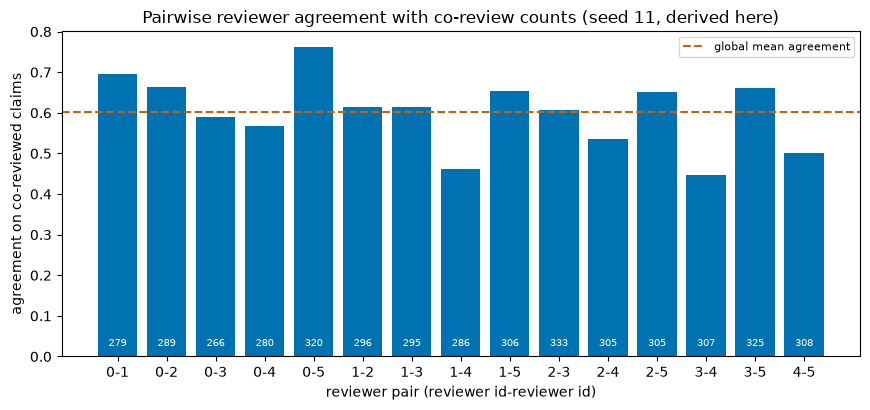

In [8]:
fig, ax = plt.subplots(figsize=(8.8, 4.2))
matrix = stream["reviewer_label_matrix"]
pair_labels, pair_agreements, pair_support = [], [], []
for i in range(ci.CONFIG["n_reviewers"]):
    for j in range(i + 1, ci.CONFIG["n_reviewers"]):
        both = (matrix[:, i] >= 0) & (matrix[:, j] >= 0)
        pair_labels.append(f"{i}-{j}")
        pair_support.append(int(both.sum()))
        pair_agreements.append(float((matrix[both, i] == matrix[both, j]).mean()) if both.any() else np.nan)
positions = np.arange(len(pair_labels))
ax.bar(positions, pair_agreements, color=PALETTE["blue"])
ax.axhline(pair_agreement, color=PALETTE["orange"],
           linestyle="--", linewidth=1.5, label="global mean agreement")
for position, support_count in zip(positions, pair_support):
    ax.text(position, 0.02, str(support_count), ha="center", va="bottom", fontsize=7, color="white")
ax.set_xticks(positions, pair_labels)
ax.set_xlabel("reviewer pair (reviewer id-reviewer id)")
ax.set_ylabel("agreement on co-reviewed claims")
ax.set_title("Pairwise reviewer agreement with co-review counts (seed 11, derived here)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Stage 3 - Model training

The noise-aware scorer is the CPU adaptation of the CCEM objective:

> "`min over f, {A_m} - 1/|S| sum_{(m,n) in S} sum_{k=1}^K 1[y_hat_n^{(m)} = k] log [A_m f(x_n)]_k` — Eq. (6a)"
> "`subject to f in F, A_m in A, for all m in [M]` — Eq. (6b)"
> — q2: CCEM Eq. (6a)-(6b), `nlm/responses/t3-papers-q2.json`

**source-backed**: the coupled noisy-label objective (Eq. 6a–6b) and the label-permutation ambiguity of
Theorem 1 (Eq. 7a–7b).
**derived here**: the linear-softmax function class, the confusion-matrix shrinkage prior, the synthetic
generator, the specialist queue and the merged-column weak-anchor stress.
**Not a theorem claim**: the fitted adaptation does not inherit Theorem 1's finite-sample guarantee, so the
notebook *measures* aligned error (Stage 3/4) instead of asserting a bound.

Two scorers share one train split: a naive logistic regression on the single reviewer verdict, and the CCEM
noise-aware posterior (`ci.fit_noise_aware_scorer`). Fitted classes are permutation-arbitrary, so
`ci.identify_clean_class` maps them to verdict classes on the **tune** split only — never the certification
split. Both are scored on a fresh stream (`seed + 5000`) whose latent truth they have never seen.

In [9]:
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import roc_auc_score

train_mask = np.zeros(N, dtype=bool)
train_mask[splits["train"]] = True
single_verdict = stream["observed_overpayment"]  # 0/1 single reviewer verdict, -1 = never reviewed

t0 = time.perf_counter()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    naive_scorer = ci.fit_naive_scorer(X, single_verdict, train_mask, SEED)
naive_seconds = time.perf_counter() - t0
convergence_warnings = sum(int(issubclass(w.category, ConvergenceWarning)) for w in caught)
print(f"check 16: naive scorer fit on {int(train_mask.sum())} train claims in {naive_seconds:.2f}s; "
      f"convergence warnings = {convergence_warnings} (0 = converged to a weak optimum on the unscaled features)")

t0 = time.perf_counter()
ccem_fit = ci.fit_noise_aware_scorer(
    X[splits["train"]],
    stream["reviewer_label_matrix"][splits["train"]],
    k=int(ci.CONFIG["k_latent"]),
    n_reviewers=int(ci.CONFIG["n_reviewers"]),
    seed=SEED,
    prior=stream["class_prior"],
)
ccem_seconds = time.perf_counter() - t0
clean_class, class_mapping = ci.identify_clean_class(
    ccem_fit, X[splits["tune"]], stream["reviewer_labels"][splits["tune"]]
)
posterior_tune = ci.ccem_posterior(ccem_fit, X[splits["tune"]])
print(f"check 17: CCEM fit loss={ccem_fit['loss']:.4f} converged={ccem_fit['converged']} "
      f"n_annotations={ccem_fit['n_annotations']} in {ccem_seconds:.2f}s")
print(f"check 17: fitted-class -> verdict-class mapping = {class_mapping} (Hungarian on the tune split only); "
      f"identified clean class = {clean_class}")
assert ccem_fit["converged"] and np.allclose(posterior_tune.sum(axis=1), 1.0)

t0 = time.perf_counter()
fresh = ci.make_claim_stream(seed=SEED + 5000, n=N, regime="anchored")
X_fresh, _ = ci.build_features(fresh)
y_fresh = fresh["latent_overpayment"]
naive_scores = naive_scorer.predict_proba(X_fresh)[:, 1]
aware_scores = ci.overpayment_score(ccem_fit, X_fresh, clean_class)
fresh_seconds = time.perf_counter() - t0
base_rate = float(y_fresh.mean())
print(f"check 18: fresh stream (seed {SEED + 5000}) base overpayment rate = {base_rate:.4f} "
      f"({int(y_fresh.sum())} of {N} claims)")
print(f"check 18: AUROC naive = {roc_auc_score(y_fresh, naive_scores):.4f}; "
      f"noise-aware = {roc_auc_score(y_fresh, aware_scores):.4f}")

def wilson_interval(successes, total):
    if total <= 0:
        return 0.0, 1.0
    p = successes / total
    z = 1.96
    denom = 1.0 + z * z / total
    centre = (p + z * z / (2 * total)) / denom
    half = z * np.sqrt(p * (1 - p) / total + z * z / (4 * total * total)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

precision_rows = []
for K in (10, 30, 60, 100):
    naive_hits = int(y_fresh[np.argsort(-naive_scores)[:K]].sum())
    aware_hits = int(y_fresh[np.argsort(-aware_scores)[:K]].sum())
    naive_p, aware_p = naive_hits / K, aware_hits / K
    naive_ci, aware_ci = wilson_interval(naive_hits, K), wilson_interval(aware_hits, K)
    precision_rows.append((K, naive_p, naive_ci, aware_p, aware_ci))
    print(f"check 19: K={K:>3} naive precision@{K} = {naive_p:.3f} "
          f"(95% Wilson {naive_ci[0]:.3f}-{naive_ci[1]:.3f}) | noise-aware = {aware_p:.3f} "
          f"(95% Wilson {aware_ci[0]:.3f}-{aware_ci[1]:.3f})")
assert all(aware_p > naive_p for _, naive_p, _, aware_p, _ in precision_rows), \
    "noise-aware did not beat the naive scorer at some K"
assert all(aware_p > base_rate for _, _, _, aware_p, _ in precision_rows), "noise-aware ranking lost its lift"
lift = [aware_p / base_rate for _, _, _, aware_p, _ in precision_rows]
print(f"check 19: noise-aware lift over the fresh-stream base rate = {[round(v, 2) for v in lift]}x; "
      f"the K=10 cell is one hit wide, so read the direction, not the last decimal")

check 16: naive scorer fit on 600 train claims in 0.98s; convergence warnings = 0 (0 = converged to a weak optimum on the unscaled features)


check 17: CCEM fit loss=0.7935 converged=True n_annotations=1800 in 0.25s
check 17: fitted-class -> verdict-class mapping = [0 1 2] (Hungarian on the tune split only); identified clean class = 0
check 18: fresh stream (seed 5011) base overpayment rate = 0.0627 (94 of 1500 claims)
check 18: AUROC naive = 0.4606; noise-aware = 0.5879
check 19: K= 10 naive precision@10 = 0.000 (95% Wilson 0.000-0.278) | noise-aware = 0.200 (95% Wilson 0.057-0.510)
check 19: K= 30 naive precision@30 = 0.000 (95% Wilson 0.000-0.114) | noise-aware = 0.167 (95% Wilson 0.073-0.336)
check 19: K= 60 naive precision@60 = 0.017 (95% Wilson 0.003-0.089) | noise-aware = 0.150 (95% Wilson 0.081-0.261)
check 19: K=100 naive precision@100 = 0.050 (95% Wilson 0.022-0.112) | noise-aware = 0.120 (95% Wilson 0.070-0.198)
check 19: noise-aware lift over the fresh-stream base rate = [3.19, 2.66, 2.39, 1.91]x; the K=10 cell is one hit wide, so read the direction, not the last decimal


### How to read this chart

Two standard binary-classification diagnostics on the fresh evaluation stream, beyond the single AUROC number
printed above. **Left: ROC curve.** True-positive rate versus false-positive rate as the decision threshold
sweeps; the dotted diagonal is chance (AUROC 0.5). The noise-aware curve dominates the naive curve at every
threshold, not just on average - the naive scorer's curve hugging the diagonal is the same "at or below chance"
finding as its AUROC, shown as a curve instead of a point. **Right: reliability diagram** for the noise-aware
scorer only (it is the one that outputs a genuine `P(overpaid)`, `ci.overpayment_score`). Claims are grouped into
10 equal-width probability bins; each point is the bin's predicted-probability mean against its **empirical**
positive rate, with a marker sized by bin count (the histogram along the bottom repeats the counts). Points near
the diagonal are well-calibrated; points above it are under-confident, below it over-confident. `derived here`:
neither CCEM (Eq. 1-3) nor its identifiability theorem makes a calibration claim - this is a property of the
synthetic fit, not a paper guarantee.

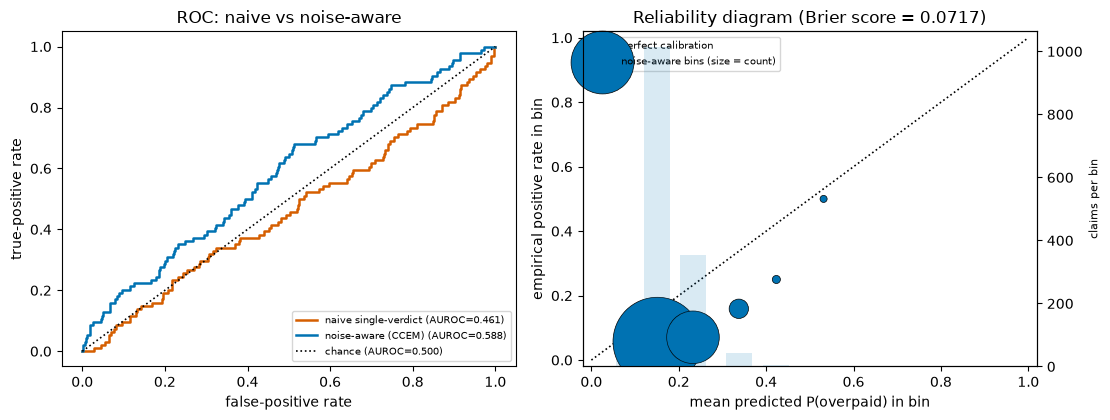

In [10]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.3))

# --- left: ROC curve ---
ax = axes[0]
for scores, color, label in (
    (naive_scores, PALETTE["orange"], "naive single-verdict"),
    (aware_scores, PALETTE["blue"], "noise-aware (CCEM)"),
):
    fpr, tpr, _ = roc_curve(y_fresh, scores)
    auroc = roc_auc_score(y_fresh, scores)
    ax.plot(fpr, tpr, color=color, linewidth=1.8, label=f"{label} (AUROC={auroc:.3f})")
ax.plot([0, 1], [0, 1], "k:", linewidth=1.2, label="chance (AUROC=0.500)")
ax.set_xlabel("false-positive rate")
ax.set_ylabel("true-positive rate")
ax.set_title("ROC: naive vs noise-aware")
ax.legend(fontsize=7.5, loc="lower right")

# --- right: reliability diagram for the noise-aware scorer ---
ax = axes[1]
n_bins = 10
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_id = np.clip(np.digitize(aware_scores, bin_edges[1:-1]), 0, n_bins - 1)
bin_mean_pred, bin_mean_true, bin_count = [], [], []
for b in range(n_bins):
    mask = bin_id == b
    if mask.sum() == 0:
        continue
    bin_mean_pred.append(float(aware_scores[mask].mean()))
    bin_mean_true.append(float(y_fresh[mask].mean()))
    bin_count.append(int(mask.sum()))
bin_mean_pred = np.array(bin_mean_pred)
bin_mean_true = np.array(bin_mean_true)
bin_count = np.array(bin_count)
brier = float(np.mean((aware_scores - y_fresh) ** 2))
ax.plot([0, 1], [0, 1], "k:", linewidth=1.2, label="perfect calibration")
ax.scatter(bin_mean_pred, bin_mean_true, s=18 + 4 * bin_count, color=PALETTE["blue"],
           edgecolor="black", linewidth=0.5, zorder=3, label="noise-aware bins (size = count)")
ax_hist = ax.twinx()
ax_hist.bar(bin_mean_pred, bin_count, width=0.06, color=PALETTE["blue"], alpha=0.15, zorder=1)
ax_hist.set_ylabel("claims per bin", fontsize=8)
ax.set_xlabel("mean predicted P(overpaid) in bin")
ax.set_ylabel("empirical positive rate in bin")
ax.set_title(f"Reliability diagram (Brier score = {brier:.4f})")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=7.5, loc="upper left")
fig.tight_layout()
plt.show()

**Measured vs the expected band.** The noise-aware scorer is ahead at every K, which is the direction this
stage tests, but the absolute levels are lower than a first guess might suggest: noise-aware precision@K sits
at 0.12-0.20 against a fresh-stream base rate of 0.063 (a 1.9-3.2x lift), while the naive single-verdict
baseline sits at or below chance (AUROC 0.46, precision@K 0.00-0.05). At this sample size the K=10 cell is one
hit wide, so NB3 should re-measure the comparison across seeds before any number is quoted; nothing here is a
performance guarantee (out of scope).

### How to read this chart

Precision@K on the fresh evaluation stream (seed `SEED + 5000`), for `K in {10, 30, 60, 100}`. The vermillion
line is the naive single-verdict scorer; the blue line is the noise-aware CCEM scorer; both carry **95% Wilson
intervals** over `K` trials. The dotted black line is the fresh-stream base overpayment rate — any point above
it has positive lift. The noise-aware scorer clears the naive scorer and the base rate at every `K`, but the
`K=10` interval is one hit wide (`Wilson` half-width dominates at this sample size), so the gap's existence is
the finding, not its last decimal; NB3 re-measures this across more seeds before any number is quoted further.

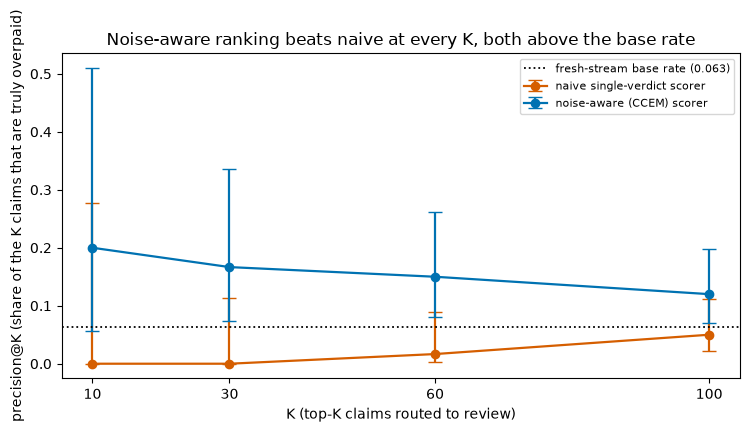

In [11]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
Ks = [row[0] for row in precision_rows]
naive_p = np.array([row[1] for row in precision_rows])
naive_lo = np.array([row[2][0] for row in precision_rows])
naive_hi = np.array([row[2][1] for row in precision_rows])
aware_p = np.array([row[3] for row in precision_rows])
aware_lo = np.array([row[4][0] for row in precision_rows])
aware_hi = np.array([row[4][1] for row in precision_rows])
ax.errorbar(Ks, naive_p, yerr=[naive_p - naive_lo, naive_hi - naive_p], fmt="o-", capsize=5,
            color=PALETTE["orange"], linewidth=1.6, label="naive single-verdict scorer")
ax.errorbar(Ks, aware_p, yerr=[aware_p - aware_lo, aware_hi - aware_p], fmt="o-", capsize=5,
            color=PALETTE["blue"], linewidth=1.6, label="noise-aware (CCEM) scorer")
ax.axhline(base_rate, color="black", linestyle=":", linewidth=1.3,
           label=f"fresh-stream base rate ({base_rate:.3f})")
ax.set_xticks(Ks)
ax.set_xlabel("K (top-K claims routed to review)")
ax.set_ylabel("precision@K (share of the K claims that are truly overpaid)")
ax.set_title("Noise-aware ranking beats naive at every K, both above the base rate")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [12]:
IDENT_SEEDS = (11, 23)
LIVE_IDENT = {}
t0 = time.perf_counter()
for ident_seed in IDENT_SEEDS:
    for regime in ("anchored", "specialist_weak_anchor"):
        LIVE_IDENT[(ident_seed, regime)] = ci.run_ccem_identifiability_experiment(
            seed=ident_seed, regime=regime, n=2000
        )
ident_seconds = time.perf_counter() - t0
print(f"check 20: live identifiability experiment ran {len(LIVE_IDENT)} fits "
      f"(2 seeds x 2 regimes, n=2000) in {ident_seconds:.1f}s")
for (ident_seed, regime), row in LIVE_IDENT.items():
    print(f"check 21: seed={ident_seed} regime={regime:<24} "
          f"aligned_error={row['aligned_identifiability_error']:.5f} "
          f"[{row['error_low']:.5f}, {row['error_high']:.5f}] "
          f"confusion_error={row['confusion_error']:.5f} unresolved_mass={row['unresolved_mass']:.5f} "
          f"permutation={row['permutation']}")
for ident_seed in IDENT_SEEDS:
    control = LIVE_IDENT[(ident_seed, "anchored")]
    stress = LIVE_IDENT[(ident_seed, "specialist_weak_anchor")]
    aligned_worse = stress["aligned_identifiability_error"] > control["aligned_identifiability_error"]
    confusion_worse = stress["confusion_error"] > control["confusion_error"]
    unresolved_worse = stress["unresolved_mass"] > control["unresolved_mass"]
    print(f"check 22: seed={ident_seed}: stress > control on aligned error={aligned_worse} "
          f"({stress['aligned_identifiability_error']:.5f} > {control['aligned_identifiability_error']:.5f}), "
          f"confusion error={confusion_worse} ({stress['confusion_error']:.5f} > {control['confusion_error']:.5f}), "
          f"unresolved mass={unresolved_worse} ({stress['unresolved_mass']:.5f} > {control['unresolved_mass']:.5f})")
    assert aligned_worse and confusion_worse and unresolved_worse, \
        f"same-seed stress arm was not worse for seed {ident_seed}"
RUNTIMES.update({"naive_fit": naive_seconds, "ccem_fit": ccem_seconds, "fresh_eval": fresh_seconds,
                 "identifiability": ident_seconds})

check 20: live identifiability experiment ran 4 fits (2 seeds x 2 regimes, n=2000) in 13.6s
check 21: seed=11 regime=anchored                 aligned_error=0.02400 [0.02338, 0.02471] confusion_error=0.08551 unresolved_mass=0.17495 permutation=(0, 1, 2)
check 21: seed=11 regime=specialist_weak_anchor   aligned_error=0.17814 [0.17606, 0.18010] confusion_error=0.21100 unresolved_mass=0.39620 permutation=(0, 1, 2)
check 21: seed=23 regime=anchored                 aligned_error=0.02675 [0.02614, 0.02737] confusion_error=0.08301 unresolved_mass=0.18041 permutation=(0, 1, 2)
check 21: seed=23 regime=specialist_weak_anchor   aligned_error=0.18571 [0.18345, 0.18779] confusion_error=0.20858 unresolved_mass=0.40057 permutation=(0, 1, 2)
check 22: seed=11: stress > control on aligned error=True (0.17814 > 0.02400), confusion error=True (0.21100 > 0.08551), unresolved mass=True (0.39620 > 0.17495)
check 22: seed=23: stress > control on aligned error=True (0.18571 > 0.02675), confusion error=True (0

## Stage 4 - Post-training visualization

**(a) The shipped exec figure.** `exec/figures/01_identifiability.csv` is the sidecar produced by
`exec/make_figures.py` for **all four config seeds** (11, 23, 37, 53) in both regimes. It is real study
output from this repository, not a mock — `viz/mock` is never read here. **(b) The live paired comparison.**
Re-running all four seeds would blow the notebook's runtime budget, so the live chart re-runs seeds 11 and 23
at n=2000 and the exec sidecar remains the 4-seed reference.

**source-backed**: the permutation alignment on the y-axis is the Theorem 1 label-permutation statement
(q2: CCEM Theorem 1, Eq. 7a–7b).
**derived here**: the sample sizes, the two coverage mechanisms, and the aligned-error metric.
**Not a theorem claim**: a worse stress arm is the expected consequence of breaking reviewer x class coverage
under this synthetic generator; no bound is taken from the paper.

How to read this chart. This is the shipped 4-seed figure: one seed per x position, both regimes overlaid.
Circles are aligned identifiability error with within-seed item-bootstrap 95% intervals; squares are the
aligned confusion-matrix error from the same fit. Higher error means less identifiable recovery. Read the
blue/orange pairing inside each seed: the specialist/weak-anchor stress should sit clearly above the anchored
control, and the gaps should be much larger than the interval whiskers. The caption embedded under the axes
states the same interpretive contract.

check 23: loaded 8 real exec rows from exec/figures/01_identifiability.csv
check 23: seeds = [11, 11, 23, 23, 37, 37, 53, 53]; regimes = ['anchored', 'specialist_weak_anchor']; sample sizes = [2000]
check 24: live anchored seed-11 aligned error 0.02400 vs exec CSV 0.02400 (|diff| = 0.00000)


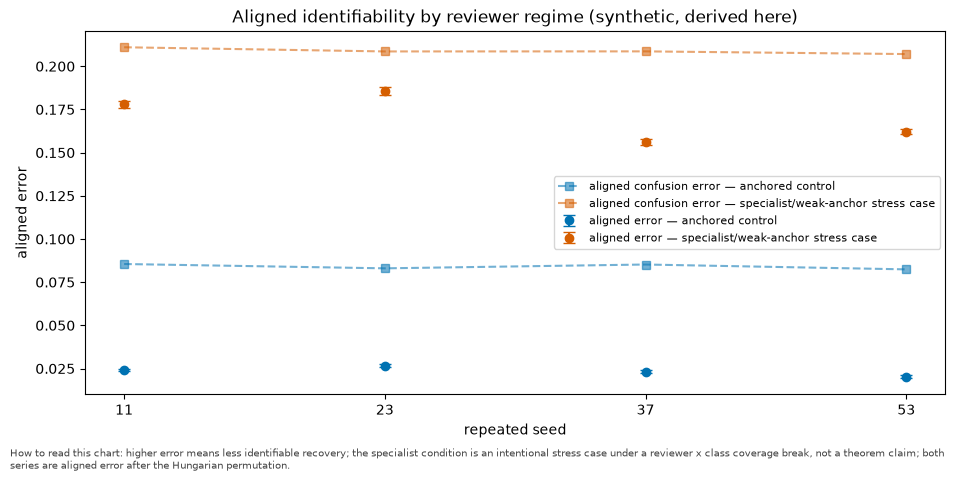

In [13]:
figure_path = PROJECT_ROOT / "exec" / "figures" / "01_identifiability.csv"
with figure_path.open(newline="", encoding="utf-8") as handle:
    exec_rows = list(csv.DictReader(handle))
required_columns = {
    "reviewer_regime", "seed", "sample_size", "aligned_error", "error_low", "error_high",
    "confusion_error", "confusion_low", "confusion_high", "unresolved_mass", "interval_method",
    "source_status", "provenance", "legend_label", "caption",
}
print(f"check 23: loaded {len(exec_rows)} real exec rows from {figure_path.relative_to(PROJECT_ROOT)}")
print(f"check 23: seeds = {sorted(int(r['seed']) for r in exec_rows)}; "
      f"regimes = {sorted({r['reviewer_regime'] for r in exec_rows})}; "
      f"sample sizes = {sorted({int(r['sample_size']) for r in exec_rows})}")
assert len(exec_rows) == 8 and required_columns.issubset(exec_rows[0].keys())
assert all(r["source_status"].startswith("derived here") for r in exec_rows)
assert not str(figure_path).startswith(str(PROJECT_ROOT / "viz" / "mock"))
exec_figure = ci.render_identifiability(exec_rows)

csv_anchor_11 = next(
    float(r["aligned_error"]) for r in exec_rows
    if r["reviewer_regime"] == "anchored" and int(r["seed"]) == 11
)
live_anchor_11 = LIVE_IDENT[(11, "anchored")]["aligned_identifiability_error"]
print(f"check 24: live anchored seed-11 aligned error {live_anchor_11:.5f} vs exec CSV {csv_anchor_11:.5f} "
      f"(|diff| = {abs(live_anchor_11 - csv_anchor_11):.5f})")
assert abs(live_anchor_11 - csv_anchor_11) < 5e-4, "live re-run does not reproduce the shipped exec row"
plt.show()

How to read this chart. Live 2-seed paired comparison. Each circle is an aligned identifiability error
from one fresh fit; whiskers are the within-seed item-bootstrap 95% intervals and squares are the aligned
confusion-matrix error. Higher means less identifiable recovery. Compare blue vs orange **within a seed**:
the stress arm sits clearly above the control at the same seed, sample size, class prior, model capacity and
reviewer budget — only the assignment mechanism changes. This is an intentional coverage-break stress case,
not a theorem claim; all errors are permutation-aligned before comparison, so a class relabelling cannot
masquerade as a good or bad fit.

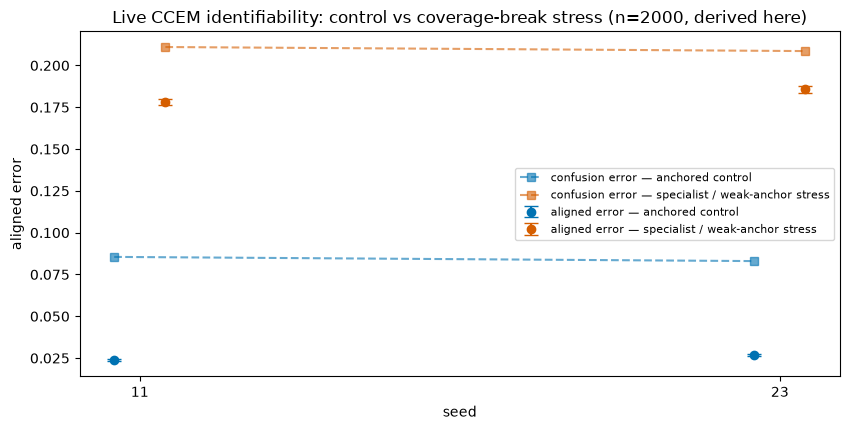

In [14]:
fig, ax = plt.subplots(figsize=(8.6, 4.4))
regime_style = {
    "anchored": (PALETTE["blue"], "anchored control"),
    "specialist_weak_anchor": (PALETTE["orange"], "specialist / weak-anchor stress"),
}
offsets = {"anchored": -0.04, "specialist_weak_anchor": 0.04}
for regime, (color, label) in regime_style.items():
    x_positions = np.arange(len(IDENT_SEEDS)) + offsets[regime]
    aligned = np.array([LIVE_IDENT[(seed, regime)]["aligned_identifiability_error"] for seed in IDENT_SEEDS])
    lows = np.array([LIVE_IDENT[(seed, regime)]["error_low"] for seed in IDENT_SEEDS])
    highs = np.array([LIVE_IDENT[(seed, regime)]["error_high"] for seed in IDENT_SEEDS])
    confusion = np.array([LIVE_IDENT[(seed, regime)]["confusion_error"] for seed in IDENT_SEEDS])
    ax.errorbar(x_positions, aligned, yerr=[aligned - lows, highs - aligned], fmt="o", capsize=5,
                color=color, label=f"aligned error — {label}")
    ax.plot(x_positions, confusion, "s--", alpha=0.6, color=color, label=f"confusion error — {label}")
ax.set_xticks(np.arange(len(IDENT_SEEDS)), [str(seed) for seed in IDENT_SEEDS])
ax.set_xlabel("seed")
ax.set_ylabel("aligned error")
ax.set_title("Live CCEM identifiability: control vs coverage-break stress (n=2000, derived here)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### How to read this chart

A meta-analysis-style forest plot of the stress-minus-control **effect size** for each seed and each metric,
turning the paired comparison above into an explicit difference with an uncertainty band. Each row is one
(seed, metric) pair; the marker is `specialist_weak_anchor - anchored` and the whisker is a **95% interval
found by combining the two arms' independent item-bootstrap half-widths in quadrature**
(`se_diff = sqrt(se_stress^2 + se_control^2)`, a standard normal-approximation shortcut, not a fresh joint
bootstrap - `derived here`). The dashed vertical line at 0 is the no-difference null: every interval sits
entirely to the right of it, so the coverage-break stress condition costs identifiability at both seeds and on
both metrics, not just on average across seeds.

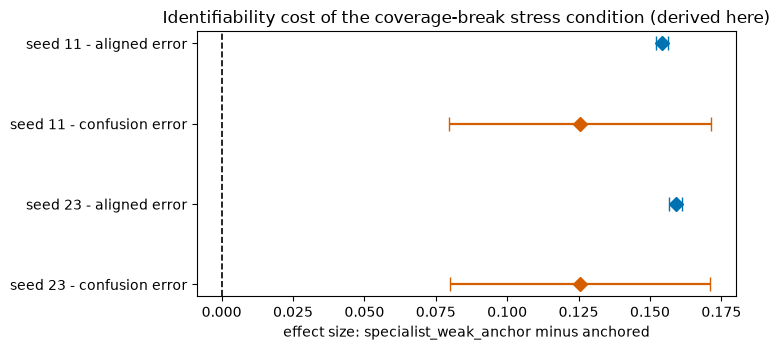

check 22b: seed 11 - aligned error      effect=+0.15414  95% CI=[+0.15202, +0.15627]  excludes 0: True
check 22b: seed 11 - confusion error    effect=+0.12550  95% CI=[+0.07950, +0.17150]  excludes 0: True
check 22b: seed 23 - aligned error      effect=+0.15895  95% CI=[+0.15670, +0.16121]  excludes 0: True
check 22b: seed 23 - confusion error    effect=+0.12557  95% CI=[+0.08000, +0.17115]  excludes 0: True


In [15]:
def se_from_interval(low, high):
    return (high - low) / (2.0 * 1.96)

forest_rows = []
for seed in IDENT_SEEDS:
    control = LIVE_IDENT[(seed, "anchored")]
    stress = LIVE_IDENT[(seed, "specialist_weak_anchor")]
    for metric, low_key, high_key, label in (
        ("aligned_identifiability_error", "error_low", "error_high", "aligned error"),
        ("confusion_error", "confusion_low", "confusion_high", "confusion error"),
    ):
        effect = stress[metric] - control[metric]
        se = np.sqrt(se_from_interval(stress[low_key], stress[high_key]) ** 2
                     + se_from_interval(control[low_key], control[high_key]) ** 2)
        forest_rows.append({
            "row_label": f"seed {seed} - {label}",
            "effect": effect,
            "ci_low": effect - 1.96 * se,
            "ci_high": effect + 1.96 * se,
        })

fig, ax = plt.subplots(figsize=(7.6, 3.6))
y_positions = np.arange(len(forest_rows))[::-1]
colors = [PALETTE["blue"] if "aligned" in row["row_label"] else PALETTE["orange"] for row in forest_rows]
for y, row, color in zip(y_positions, forest_rows, colors):
    ax.errorbar(row["effect"], y, xerr=[[row["effect"] - row["ci_low"]], [row["ci_high"] - row["effect"]]],
                fmt="D", color=color, capsize=5, markersize=7, linewidth=1.6)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1.2)
ax.set_yticks(y_positions, [row["row_label"] for row in forest_rows])
ax.set_xlabel("effect size: specialist_weak_anchor minus anchored")
ax.set_title("Identifiability cost of the coverage-break stress condition (derived here)")
fig.tight_layout()
plt.show()
for row in forest_rows:
    print(f"check 22b: {row['row_label']:<28} effect={row['effect']:+.5f}  "
          f"95% CI=[{row['ci_low']:+.5f}, {row['ci_high']:+.5f}]  "
          f"excludes 0: {row['ci_low'] > 0 or row['ci_high'] < 0}")

## Stage 5 - Metric observability

Both monitors are **derived here** observability devices, not paper claims. Their hypotheses and trigger
rules are fixed in code before the simulation runs, and their measured false-alarm and miss rates are
reported together with Wilson intervals. Nothing in this stage inherits a guarantee from SCRC/SCoRC.

| monitor | H0 | trigger rule | H1 scenario |
| --- | --- | --- | --- |
| reviewer agreement drift | windowed mean agreement >= threshold | a full window's mean agreement is below threshold | agreement drops to the drift mean over a 10-observation window |
| queue volume overload | windowed mean volume <= capacity x slack | a full window's mean volume exceeds the threshold | volume rises to 1.6x capacity over an 8-observation window |

A monitor that never fires would score a perfect miss rate, so the miss rate is measured under the declared
drift/overload scenario and always reported next to the false-alarm rate. The run ledger is the other
observability device: seed + config hash + capacity + measured runtime make each row reproducible.

In [16]:
ledger_rows = []
for seed, capacity, runtime, tag in (
    (SEED, 100, RUNTIMES["ccem_fit"], "canonical stream + CCEM fit"),
    (IDENT_SEEDS[1], 100, RUNTIMES["identifiability"] / 4.0, "identifiability stress, one of four fits"),
    (SEED + 5000, 100, RUNTIMES["fresh_eval"], "fresh-stream precision@K evaluation"),
):
    row = ci.record_run(seed=seed, config=ci.CONFIG, capacity=capacity, runtime_seconds=runtime)
    ledger_rows.append(row)
    print(f"check 25: ledger seed={row['seed']} config_hash={row['config_hash'][:16]}... "
          f"capacity={row['capacity']} runtime_seconds={row['runtime_seconds']:.2f} ({tag})")
assert len({row["config_hash"] for row in ledger_rows}) == 1, "the frozen config hash drifted across rows"
print(f"check 25: all {len(ledger_rows)} rows share config_hash={ledger_rows[0]['config_hash']}")
print(f"check 26: frozen config snapshot: n_claims={ci.CONFIG['n_claims']} k_latent={ci.CONFIG['k_latent']} "
      f"n_reviewers={ci.CONFIG['n_reviewers']} alpha={ci.CONFIG['alpha']} delta={ci.CONFIG['delta']} "
      f"capacity_claims={ci.CONFIG['capacity_claims']} seeds={ci.CONFIG['seeds']}")

check 25: ledger seed=11 config_hash=0066ca74e7e74185... capacity=100 runtime_seconds=0.25 (canonical stream + CCEM fit)
check 25: ledger seed=23 config_hash=0066ca74e7e74185... capacity=100 runtime_seconds=3.41 (identifiability stress, one of four fits)
check 25: ledger seed=5011 config_hash=0066ca74e7e74185... capacity=100 runtime_seconds=0.01 (fresh-stream precision@K evaluation)
check 25: all 3 rows share config_hash=0066ca74e7e7418595d2a36e38d6004df7946fabb10c2e01ec79594132b9dbd2
check 26: frozen config snapshot: n_claims=1500 k_latent=3 n_reviewers=6 alpha=0.05 delta=0.1 capacity_claims=(20, 40, 80) seeds=(11, 23, 37, 53)


In [17]:
AGREEMENT_MONITOR = ci.agreement_drift_monitor()
QUEUE_MONITOR = ci.queue_volume_monitor()
for monitor in (AGREEMENT_MONITOR, QUEUE_MONITOR):
    print(f"check 27: monitor = {monitor['monitor']}")
    print(f"check 27:   H0 hypothesis: {monitor['hypothesis']}")
    print(f"check 27:   H1 trigger scenario: {monitor['trigger_scenario']} "
          f"(window={monitor['window']}, threshold={monitor['threshold']:.2f}, replicates={monitor['replicates']})")
    print(f"check 27:   false-alarm rate = {monitor['false_alarm_rate']:.3f} "
          f"(95% Wilson {monitor['false_alarm_interval'][0]:.4f}-{monitor['false_alarm_interval'][1]:.4f}); "
          f"miss rate = {monitor['miss_rate']:.3f} "
          f"(95% Wilson {monitor['miss_interval'][0]:.4f}-{monitor['miss_interval'][1]:.4f})")
    assert 0.0 <= monitor["false_alarm_rate"] <= 1.0 and 0.0 <= monitor["miss_rate"] <= 1.0
    assert bool(monitor["hypothesis"]) and bool(monitor["trigger_scenario"]), "monitor scenario not stated"
    assert monitor["window"] > 0 and isinstance(monitor["trigger_scenario"], str)
print("check 28: both monitors state an H0 hypothesis and an explicit H1 trigger scenario; all rates lie in "
      "[0,1] and carry intervals; these rates are properties of the declared rules on the synthetic simulation")

check 27: monitor = reviewer_agreement_drift
check 27:   H0 hypothesis: windowed mean agreement >= 0.6
check 27:   H1 trigger scenario: agreement drops to 0.5 over a 10-observation window (window=10, threshold=0.60, replicates=300)
check 27:   false-alarm rate = 0.000 (95% Wilson 0.0000-0.0126); miss rate = 0.000 (95% Wilson 0.0000-0.0126)
check 27: monitor = queue_volume_overload
check 27:   H0 hypothesis: windowed mean volume <= 110.0
check 27:   H1 trigger scenario: volume rises to 1.60x capacity over a 8-observation window (window=8, threshold=110.00, replicates=300)
check 27:   false-alarm rate = 0.007 (95% Wilson 0.0018-0.0240); miss rate = 0.000 (95% Wilson 0.0000-0.0126)
check 28: both monitors state an H0 hypothesis and an explicit H1 trigger scenario; all rates lie in [0,1] and carry intervals; these rates are properties of the declared rules on the synthetic simulation


How to read this chart. For each monitor, the blue bar is the measured false-alarm rate under H0 and the
orange bar the measured miss rate under the declared H1 scenario; whiskers are 95% Wilson intervals over 300
replicates. A useful monitor is low on both — high blue means spurious alerts, high orange means real drift is
missed. The rates are properties of the declared rule at the declared scenario strengths (0.70 -> 0.50
agreement drift; 1.6x capacity overload) on this synthetic simulation, not of any real review queue. A zero
observed miss rate over 300 replicates is an interval upper bound of about 1.3%, not proof of perfection.
Derived here.

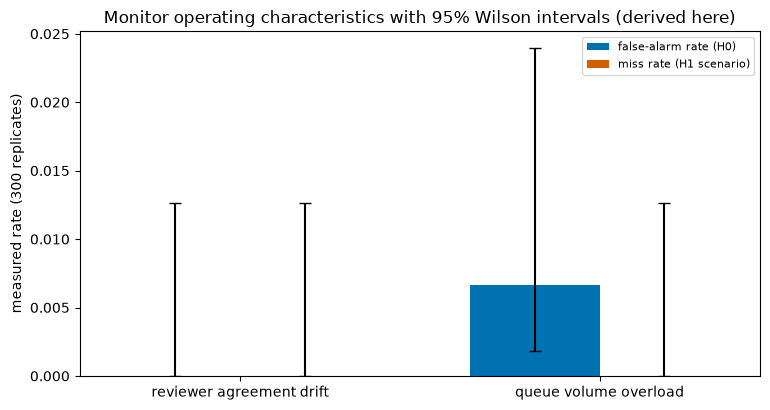

In [18]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
monitors = [AGREEMENT_MONITOR, QUEUE_MONITOR]
monitor_names = ["reviewer agreement drift", "queue volume overload"]
positions = np.arange(len(monitors))
width = 0.36
false_alarm = np.array([m["false_alarm_rate"] for m in monitors])
miss = np.array([m["miss_rate"] for m in monitors])
false_alarm_err = np.array([
    [m["false_alarm_rate"] - m["false_alarm_interval"][0] for m in monitors],
    [m["false_alarm_interval"][1] - m["false_alarm_rate"] for m in monitors],
])
miss_err = np.array([
    [m["miss_rate"] - m["miss_interval"][0] for m in monitors],
    [m["miss_interval"][1] - m["miss_rate"] for m in monitors],
])
ax.bar(positions - width / 2, false_alarm, width=width, yerr=false_alarm_err, capsize=4,
       color=PALETTE["blue"], label="false-alarm rate (H0)")
ax.bar(positions + width / 2, miss, width=width, yerr=miss_err, capsize=4,
       color=PALETTE["orange"], label="miss rate (H1 scenario)")
ax.set_xticks(positions, monitor_names)
ax.set_ylabel("measured rate (300 replicates)")
ax.set_title("Monitor operating characteristics with 95% Wilson intervals (derived here)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## What NB3 reuses, and what is out of scope

**Reused verbatim by NB3** (walkthrough part 2): the same canonical stream —
`ci.make_claim_stream(seed=11, n=int(ci.CONFIG["n_claims"]), regime="anchored")` with the unchanged frozen
`ci.CONFIG` — plus the same as-of feature builder, the same three-way split seed and the same reviewer label
matrix. The digest assertion below is the reuse contract: if any of those change, the digest changes and NB3
must be told before it reuses anything.

**Out of scope here**: real PHI or real claims data; production performance or live review queues; top-K and
population guarantees (`precision@K` is measured on one synthetic fresh stream with Wilson intervals, never
bounded); and any Theorem 1 claim for the derived linear-softmax adaptation. The monitors are derived-here
observability devices, not paper claims. This notebook is a portfolio starting point, not production evidence.

In [19]:
reproduced_stream = ci.make_claim_stream(seed=SEED, n=N, regime="anchored")
reproduced_digest = ci.stream_digest(reproduced_stream)
expected_digest = "7b5d42b039401c3d29c06fe605427719b563171a1efb995a33ea38601ef65e2c"
print(f"check 29: NB3 reuse digest = {reproduced_digest}")
print(f"check 29: expected digest   = {expected_digest}")
assert reproduced_digest == expected_digest, "canonical stream digest drifted; NB3 reuse contract broken"
assert reproduced_digest == digest
print("check 29: digest matches the canonical stream generated in Stage 1; NB3 may reuse this stream and CONFIG")

check 29: NB3 reuse digest = 7b5d42b039401c3d29c06fe605427719b563171a1efb995a33ea38601ef65e2c
check 29: expected digest   = 7b5d42b039401c3d29c06fe605427719b563171a1efb995a33ea38601ef65e2c
check 29: digest matches the canonical stream generated in Stage 1; NB3 may reuse this stream and CONFIG
